# 01 — Exploratory Data Analysis

Avant de coder une stratégie, on prend le temps de regarder à quoi ressemblent les données. Univers : TLT (long), IEF (intermédiaire), SHY (court). Variable macro : la courbe des taux US (2Y, 10Y, spread 2s10s).

L'objectif de ce notebook est de poser des bases propres pour le `02_backtest_and_strategy.ipynb`. Pas de stratégie ici, juste de la lecture de données.

## 1. Sources des données

Deux sources, toutes les deux gratuites et publiques.

Pour les ETFs, c'est Yahoo Finance via `yfinance` :

| Ticker | ETF | Duration |
|---|---|---|
| TLT | iShares 20+ Year Treasury Bond | Long |
| IEF | iShares 7-10 Year Treasury Bond | Intermédiaire |
| SHY | iShares 1-3 Year Treasury Bond | Court |

Pour les taux US, c'est FRED (Federal Reserve Bank of St. Louis), via leur endpoint CSV public — pas de clé API à demander.

| Série FRED | Description |
|---|---|
| DGS2 | Taux du Trésor US 2 ans, constant maturity |
| DGS10 | Taux du Trésor US 10 ans, constant maturity |

Quelques choix techniques à expliquer :

On démarre en 2003 parce que c'est la première année où les trois ETFs sont cotés sans trou (TLT a démarré mi-2002). Données daily, prix `auto_adjust=True` côté yfinance pour avoir des prix total return (splits + dividendes inclus). Sans ça on aurait un biais systématique vers le bas sur les ETFs obligataires qui détachent un coupon mensuel.

Tout passe par un cache parquet dans `data/raw/` (géré par `src/data.py`), donc une fois la première exécution faite, le notebook tourne hors ligne.

## 2. Imports & configuration

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_all

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)  # graine fixée pour reproductibilité (bootstrap, walk-forward)

## 3. Chargement des données

`load_all()` retourne un dict avec les prix ETF, les yields FRED et leur version alignée sur le calendrier ETF (forward-fill là où FRED a un trou que yfinance n'a pas, typiquement le Columbus Day ou le Veterans Day).

In [2]:
data = load_all()
prices = data["prices"]
yields = data["yields_aligned"]

print("Prices :", prices.shape, prices.index.min().date(), "→", prices.index.max().date())
print("Yields :", yields.shape, yields.index.min().date(), "→", yields.index.max().date())
prices.head()

Prices : (5882, 3) 2003-01-02 → 2026-05-19
Yields : (5882, 2) 2003-01-02 → 2026-05-19


Ticker,TLT,IEF,SHY
date,,,
2003-01-02,39.0742,43.0816,52.5218
2003-01-03,39.1648,43.1528,52.5283
2003-01-06,39.0606,43.0461,52.4962
2003-01-07,39.2010,43.1832,52.5346
2003-01-08,39.3958,43.2848,52.5795


In [3]:
yields.head()

,DGS2,DGS10
date,,
2003-01-02,1.8000,4.0700
2003-01-03,1.7900,4.0500
2003-01-06,1.8400,4.0900
2003-01-07,1.7700,4.0400
2003-01-08,1.7100,4.0000


## 4. Nettoyage

Trois choses à vérifier avant d'aller plus loin : missing values, doublons d'index, outliers de returns.

In [4]:
print("Missing values — prices :")
print(prices.isna().sum())
print("\nMissing values — yields (après ffill sur calendrier ETF) :")
print(yields.isna().sum())
print("\nDoublons d'index :", prices.index.duplicated().sum(), "|", yields.index.duplicated().sum())

Missing values — prices :
Ticker
TLT    0
IEF    0
SHY    0
dtype: int64

Missing values — yields (après ffill sur calendrier ETF) :
DGS2     0
DGS10    0
dtype: int64

Doublons d'index : 0 | 0


In [5]:
returns = prices.pct_change().dropna()

z = (returns - returns.mean()) / returns.std()
outliers = (z.abs() > 5).sum()
print("Jours avec |z| > 5 par ticker :")
print(outliers)

worst = pd.DataFrame({
    "date": returns.idxmin().dt.strftime("%Y-%m-%d"),
    "ret_%": (returns.min() * 100).round(2),
})
print("\nWorst day per ticker :")
print(worst)

Jours avec |z| > 5 par ticker :
Ticker
TLT     8
IEF     6
SHY    19
dtype: int64

Worst day per ticker :
              date   ret_%
Ticker                    
TLT     2020-03-17 -6.6700
IEF     2020-03-17 -2.5100
SHY     2009-06-05 -0.6600


Pour les outliers, on ne touche à rien. Les jours où TLT fait −6.67% (17 mars 2020, liquidity crunch COVID) ou où SHY a son pire jour (5 juin 2009, repricing post-FOMC) sont des jours de marché réels. Les écrêter biaiserait le backtest dans le mauvais sens — on les laisse tels quels.

## 5. Statistiques descriptives

On regarde mean / vol / Sharpe pour situer les trois ETFs entre eux, puis la matrice de corrélation, puis un test de stationnarité sur le spread (pertinent parce que c'est notre signal candidat).

In [6]:
ANN = 252

stats = pd.DataFrame({
    "mean_ann_%":   returns.mean() * ANN * 100,
    "vol_ann_%":    returns.std() * np.sqrt(ANN) * 100,
    "sharpe":       returns.mean() / returns.std() * np.sqrt(ANN),
    "skew":         returns.skew(),
    "kurt":         returns.kurt(),
    "min_day_%":    returns.min() * 100,
    "max_day_%":    returns.max() * 100,
})
stats.round(2)

,mean_ann_%,vol_ann_%,sharpe,skew,kurt,min_day_%,max_day_%
Ticker,,,,,,,
TLT,4.2500,14.3400,0.3000,0.0700,3.5100,-6.6700,7.5200
IEF,3.5300,6.7800,0.5200,0.1100,2.6000,-2.5100,3.4300
SHY,1.9200,1.5100,1.2700,0.3200,7.3400,-0.6600,1.0000


In [7]:
print("Corrélation des returns daily :")
returns.corr().round(3)

Corrélation des returns daily :


Ticker,TLT,IEF,SHY
Ticker,,,
TLT,1.0000,0.9110,0.5840
IEF,0.9110,1.0000,0.7720
SHY,0.5840,0.7720,1.0000


In [8]:
from src.robustness import adf_test

spread_for_adf = (yields["DGS10"] - yields["DGS2"]).dropna()
adf_spread = adf_test(spread_for_adf)
adf_returns = {t: adf_test(returns[t]) for t in returns.columns}

print("Test de stationnarité ADF (H0 : non stationnaire ; p < 0.05 → stationnaire) :")
print(f"  Spread 2s10s : ADF = {adf_spread['adf_stat']:.2f}, p = {adf_spread['p_value']:.3f}"
      f"  → {'stationnaire' if adf_spread['is_stationary'] else 'non stationnaire'}")
for t, r in adf_returns.items():
    print(f"  Returns {t:3s}   : ADF = {r['adf_stat']:.2f}, p = {r['p_value']:.2e}"
          f"  → {'stationnaire' if r['is_stationary'] else 'non stationnaire'}")

Test de stationnarité ADF (H0 : non stationnaire ; p < 0.05 → stationnaire) :
  Spread 2s10s : ADF = -1.77, p = 0.395  → non stationnaire
  Returns TLT   : ADF = -14.79, p = 2.18e-27  → stationnaire
  Returns IEF   : ADF = -57.60, p = 0.00e+00  → stationnaire
  Returns SHY   : ADF = -11.84, p = 7.77e-22  → stationnaire


Sur le spread, le test ADF ne rejette pas la racine unitaire (p ≈ 0.40). Donc le spread n'est pas stationnaire au sens strict — ce qui est attendu, il dérive avec le cycle macro et peut rester sur un même signe pendant des années. Côté returns ETF par contre, l'ADF rejette franchement la non-stationnarité (p ≈ 0 pour les trois), donc nos rendements eux sont OK.

À retenir pour la suite : on ne peut pas traiter le spread comme s'il revenait à zéro. Si on construit un signal, il faudra qu'il soit régime-driven (classification du spread en états), pas mean-reversion-driven.

Ce qui frappe en premier : TLT et IEF sont corrélés à 0.91. Ils répondent quasi à la même variable d'état — le 10Y. SHY est à 0.58 avec TLT, c'est lui le vrai diversifier. Côté risque, TLT a une vol annuelle de ~14%, ce qui le met au niveau d'un ETF actions large cap. "Treasury" ne veut pas dire "safe" sans nuance, surtout sur 20+ ans de maturité.

## 6. Visualisations

Quatre graphes pour avoir une vue rapide : les prix normalisés, le spread 2s10s avec les périodes d'inversion grisées, la vol roulante 3 mois, et la matrice de corrélation.

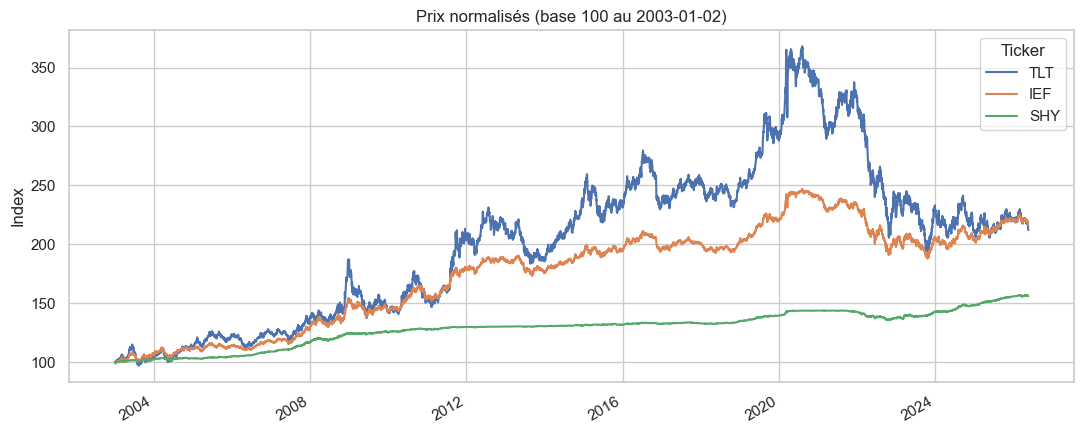

In [9]:
norm = prices / prices.iloc[0] * 100
fig, ax = plt.subplots(figsize=(11, 4.5))
norm.plot(ax=ax)
ax.set_title("Prix normalisés (base 100 au 2003-01-02)")
ax.set_ylabel("Index")
ax.set_xlabel("")
plt.tight_layout()

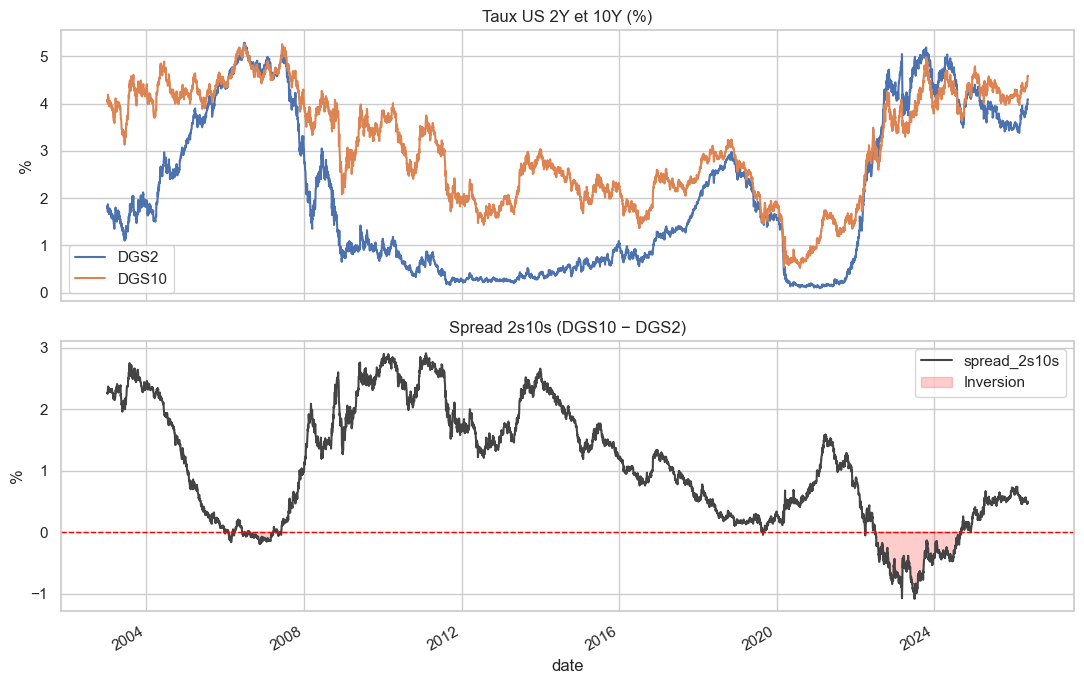

In [10]:
yields["spread_2s10s"] = yields["DGS10"] - yields["DGS2"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
yields[["DGS2", "DGS10"]].plot(ax=axes[0])
axes[0].set_title("Taux US 2Y et 10Y (%)")
axes[0].set_ylabel("%")

yields["spread_2s10s"].plot(ax=axes[1], color="#444")
axes[1].axhline(0, color="red", lw=1, ls="--")
axes[1].fill_between(yields.index, 0, yields["spread_2s10s"], where=yields["spread_2s10s"] < 0, color="red", alpha=0.2, label="Inversion")
axes[1].set_title("Spread 2s10s (DGS10 − DGS2)")
axes[1].set_ylabel("%")
axes[1].legend(loc="upper right")
plt.tight_layout()

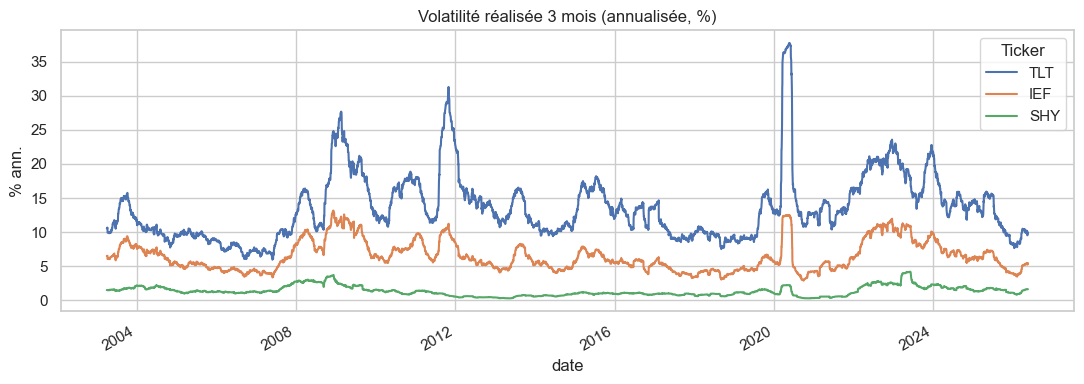

In [11]:
vol = returns.rolling(63).std() * np.sqrt(ANN) * 100
fig, ax = plt.subplots(figsize=(11, 4))
vol.plot(ax=ax)
ax.set_title("Volatilité réalisée 3 mois (annualisée, %)")
ax.set_ylabel("% ann.")
plt.tight_layout()

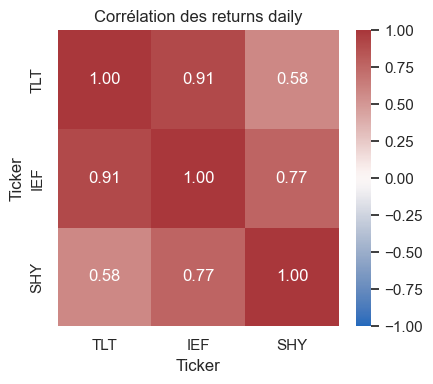

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(returns.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Corrélation des returns daily")
plt.tight_layout()

## 7. Premières intuitions de signal

L'idée naïve qu'on veut tester : est-ce que la forme de la courbe nous dit quelque chose sur la performance forward des ETFs ?

Logique économique : quand la courbe s'inverse (2Y > 10Y), c'est historiquement un signal de fin de cycle. La Fed monte les taux courts agressivement, le 2Y se vend mal, les ETFs longs prennent cher. Quand la courbe se re-pentifie après une récession, la Fed coupe les taux, les ETFs longs en profitent.

On fait le test le plus simple possible : on coupe l'historique en deux régimes (spread positif vs négatif), et on regarde le return moyen forward 21 jours dans chaque cas.

In [13]:
regime = np.where(yields["spread_2s10s"] < 0, "inverted", "normal")
regime = pd.Series(regime, index=yields.index, name="regime")

fwd_21d = prices.pct_change(21).shift(-21)

grp = fwd_21d.groupby(regime)
perf_by_regime = pd.concat({
    "mean_%": grp.mean() * 100,
    "std_%":  grp.std() * 100,
    "count":  grp.count(),
}, axis=1).round(3)
print("Performance forward 21 jours par régime de courbe :")
perf_by_regime

Performance forward 21 jours par régime de courbe :


mean_%                std_%               count            
Ticker       TLT    IEF    SHY    TLT    IEF    SHY   TLT   IEF   SHY
regime                                                               
inverted -0.1790 0.1260 0.3020 4.4360 2.2120 0.5780   784   784   784
normal    0.4340 0.3250 0.1390 3.7860 1.8430 0.3920  5077  5077  5077

Part de l'historique en régime inversé : 13.3%


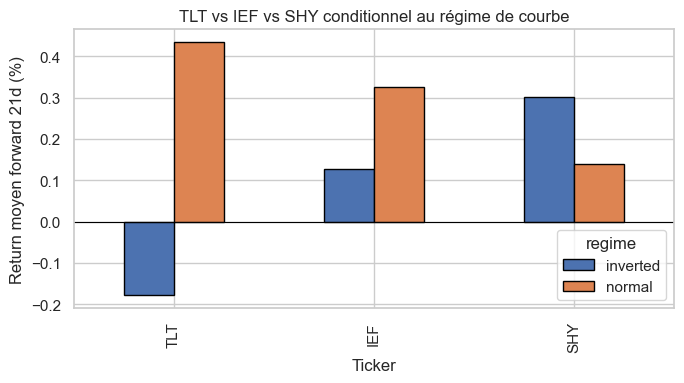

In [14]:
share_inverted = (regime == "inverted").mean()
print(f"Part de l'historique en régime inversé : {share_inverted:.1%}")

fwd_mean = fwd_21d.groupby(regime).mean()
ax = (fwd_mean * 100).T.plot(kind="bar", figsize=(7, 4), edgecolor="black")
ax.set_ylabel("Return moyen forward 21d (%)")
ax.set_title("TLT vs IEF vs SHY conditionnel au régime de courbe")
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()

Premier signe que la thèse tient : en régime inversé, TLT a un return forward 21j moyen négatif (−0.18%) tandis que SHY reste positif (+0.30%). Le sort n'est pas violent mais il est dans le bon sens, et c'est cohérent avec la story macro.

Attention quand même : le bucketing binaire est grossier (inversé / pas inversé). On ne va pas en faire un signal direct — c'est juste un sanity check pour valider que ça vaut le coup de creuser dans le notebook 02 avec une vraie segmentation.

## 8. Conclusion & next steps

Ce qu'on retient :

Les données sont propres (5 800+ jours, pas de NaN après alignement, prix déjà ajustés). TLT et IEF sont quasi-redondants (corr 0.91), SHY est le diversifier. Le spread n'est pas stationnaire, mais conditionnellement à son signe il discrimine la performance forward des ETFs — donc il y a un edge informationnel à exploiter, à condition de le construire comme un signal de régime et pas comme un signal de retour à la moyenne.

Direction pour le notebook 02 : on part sur une allocation discrète SHY / IEF / TLT pilotée par le niveau du spread. Puis on raffine avec des coûts, du slippage, et on regardera si on peut ajouter une couche risk management (probablement un filtre trend pour ne pas tenir TLT en plein effondrement style 2022).